# CS-4063 — Natural Language Processing | Assignment 3
## Transformer-based Review Understanding with RAG-Enhanced Explanation Generation
**University:** FAST National University of Computer & Emerging Sciences  
**Course:** CS-4063 Natural Language Processing  



### System Overview
```
Amazon Reviews (3 categories, 30k–45k samples)
          │
          ▼
    Preprocessing  (clean → tokenise → vocab → encode → split)
          │
          ▼
  Part A: Encoder-Only Transformer  ──► embeddings saved to disk
          │                                      │
          ▼                                      ▼
  Part B: Retrieval Module  ◄── cosine similarity on saved embeddings
          │
          ▼
  Part C: Decoder-Only Transformer  (RAG input → explanation text)
```

---
## Section 0 — Environment Setup & Global Hyperparameters

All hyperparameters live in one place so they are easy to tune.  
See **Section 8** for the full hyperparameter tuning log.

In [1]:
import os, re, json, gzip, math, random, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*55}")
print(f"  Device        : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU Name      : {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"{'='*55}")

os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)
print("\n  models/ and results/ directories ready.")

# ── Hyperparameters ────────────────────────────────────────────────────────
# Encoder
MAX_SEQ_LEN    = 96     # max tokens per review (shorter = much faster)
VOCAB_MIN_FREQ = 4      # prune rare tokens
EMBED_DIM      = 128    # d_model for both encoder and decoder
NUM_HEADS      = 4      # attention heads  (d_k = 32 per head)
NUM_ENC_LAYERS = 2      # encoder depth (2 is fast, 3 gives marginal gains)
FF_DIM         = 256    # FFN hidden size
DROPOUT        = 0.1

# Decoder
DEC_MAX_LEN    = 80     # decoder sequence length
NUM_DEC_LAYERS = 2

# Training
BATCH_SIZE     = 128    # larger batch = faster (use 64 if OOM)
ENC_EPOCHS     = 8      # encoder epochs
DEC_EPOCHS     = 8      # decoder epochs
LR             = 5e-4

# RAG
TOP_K          = 3      # neighbours to retrieve
MAX_GEN_LEN    = 28     # max new tokens at inference

print("\n  Hyperparameters loaded:")
print(f"    MAX_SEQ_LEN={MAX_SEQ_LEN}  EMBED_DIM={EMBED_DIM}  HEADS={NUM_HEADS}")
print(f"    ENC_LAYERS={NUM_ENC_LAYERS}  DEC_LAYERS={NUM_DEC_LAYERS}  FF_DIM={FF_DIM}")
print(f"    BATCH={BATCH_SIZE}  LR={LR}  ENC_EPOCHS={ENC_EPOCHS}  DEC_EPOCHS={DEC_EPOCHS}")
print(f"    TOP_K={TOP_K}  MAX_GEN_LEN={MAX_GEN_LEN}")

  Device        : cpu

  models/ and results/ directories ready.

  Hyperparameters loaded:
    MAX_SEQ_LEN=96  EMBED_DIM=128  HEADS=4
    ENC_LAYERS=2  DEC_LAYERS=2  FF_DIM=256
    BATCH=128  LR=0.0005  ENC_EPOCHS=8  DEC_EPOCHS=8
    TOP_K=3  MAX_GEN_LEN=28


---
## Section 1 — Dataset Loading

We combine three Amazon product categories to ensure domain diversity:

| Category | Domain | Reviews |
|---|---|---|
| **Appliances** | Household appliances (vacuums, refrigerators, etc.) | ≤ 15 000 |
| **Luxury Beauty** | High-end cosmetics, skincare, fragrances | ≤ 15 000 |
| **Video Games** | Gaming consoles, games, peripherals | ≤ 15 000 |

**Total target: 30 000–45 000 samples** as required by the assignment.

Each sample contains:
- `text` — the review body (string)
- `rating` — star rating 1–5 (integer)
- `category` — which product domain (string)

Reviews with fewer than 5 words are discarded as they carry no useful signal.

In [2]:
def load_amazon_gz(filepath, max_samples=15000):
    """
    Stream-load a gzipped Amazon review JSON-lines file.
    We parse line by line to avoid loading the entire file into RAM.
    Only reviews with actual text and a rating are kept.
    """
    records = []
    print(f"  Loading {filepath} ...", end=' ', flush=True)
    t0 = time.time()
    with gzip.open(filepath, 'rt', encoding='utf-8') as fh:
        for line in fh:
            if len(records) >= max_samples:
                break
            try:
                obj    = json.loads(line.strip())
                text   = obj.get('reviewText', '').strip()
                rating = obj.get('overall', None)
                if text and rating is not None and len(text.split()) >= 5:
                    records.append({'text': text, 'rating': int(rating)})
            except (json.JSONDecodeError, KeyError):
                continue
    elapsed = time.time() - t0
    print(f"loaded {len(records):,} reviews in {elapsed:.1f}s")
    return records

# Load all three categories
FILES = {
    'Appliances':    'Appliances.json.gz',
    'Luxury_Beauty': 'Luxury_Beauty.json.gz',
    'Video_Games':   'Video_Games.json.gz',
}

print("Loading Amazon Review datasets...")
print("-" * 50)
all_records = []
for category, fname in FILES.items():
    batch = load_amazon_gz(fname, max_samples=15000)
    for r in batch:
        r['category'] = category
    all_records.extend(batch)

# Shuffle to mix categories evenly
random.shuffle(all_records)

print("-" * 50)
print(f"  Total reviews loaded : {len(all_records):,}")
print()

# Per-category breakdown
cat_counts = Counter(r['category'] for r in all_records)
for cat, cnt in cat_counts.items():
    print(f"    {cat:20s}: {cnt:,} reviews  ({cnt/len(all_records)*100:.1f}%)")

# Rating distribution
print()
print("  Rating distribution across all categories:")
rc = Counter(r['rating'] for r in all_records)
for star in sorted(rc):
    bar = '█' * (rc[star] // 500)
    print(f"    {star}★  {bar}  {rc[star]:,}")

Loading Amazon Review datasets...
--------------------------------------------------
  Loading Appliances.json.gz ... loaded 15,000 reviews in 0.1s
  Loading Luxury_Beauty.json.gz ... loaded 15,000 reviews in 0.1s
  Loading Video_Games.json.gz ... loaded 15,000 reviews in 0.2s
--------------------------------------------------
  Total reviews loaded : 45,000

    Luxury_Beauty       : 15,000 reviews  (33.3%)
    Video_Games         : 15,000 reviews  (33.3%)
    Appliances          : 15,000 reviews  (33.3%)

  Rating distribution across all categories:
    1★  ███████  3,904
    2★  ███  1,965
    3★  ██████  3,330
    4★  █████████████  6,740
    5★  ██████████████████████████████████████████████████████████  29,061


---
## Section 2 — Preprocessing Pipeline

The preprocessing pipeline follows exactly the steps outlined in the assignment brief.

### 2.1 Label Definitions

**Task 1 — Sentiment Classification** (3 classes, primary task)  
This is the main task defined by the assignment.
| Rating | Label | Class ID |
|---|---|---|
| 1–2 stars | Negative | 0 |
| 3 stars | Neutral | 1 |
| 4–5 stars | Positive | 2 |

**Task 2 — Helpfulness Bucket** (3 classes, derived feature — our choice)  
We define "helpfulness" based on a combination of review length and lexical diversity.  
A review with more unique words relative to its total length tends to be more informative.  
*Justification:* This is entirely predictable from text alone (no metadata needed), and it forces the encoder to attend to both content depth and vocabulary richness — a useful inductive bias.
| Condition | Label | Class ID |
|---|---|---|
| Unique word ratio < 0.45 OR word count < 20 | Low helpfulness | 0 |
| Unique word ratio 0.45–0.65 AND word count 20–79 | Medium helpfulness | 1 |
| Unique word ratio > 0.65 AND word count ≥ 80 | High helpfulness | 2 |

### 2.2 Text Cleaning
- Convert to lowercase
- Strip HTML tags
- Remove non-alphanumeric characters (preserve apostrophes for contractions)
- Collapse multiple spaces

### 2.3 Tokenization
Simple whitespace tokenisation after cleaning.  
We intentionally avoid sub-word tokenisation to keep the implementation from-scratch.

### 2.4 Vocabulary Construction
Built exclusively from **training data** to prevent any data leakage.  
Tokens appearing fewer than `VOCAB_MIN_FREQ=4` times are replaced by `<UNK>`.  
Special tokens: `<PAD>=0`, `<UNK>=1`, `<BOS>=2`, `<EOS>=3`.

### 2.5 Padding & Truncation
Fixed sequence length of `MAX_SEQ_LEN=96` tokens.  
Shorter sequences are right-padded with `<PAD>`.  
Longer sequences are truncated from the right.

In [3]:
# ── Step 1: Label assignment ──────────────────────────────────────────────
def rating_to_sentiment(r):
    """3-class sentiment label from star rating."""    
    if r <= 2:  return 0   # Negative
    elif r == 3: return 1  # Neutral
    else:        return 2  # Positive

def compute_helpfulness(text):
    """
    Derived feature: helpfulness bucket based on lexical diversity + length.
    Lexical diversity = unique_words / total_words (type-token ratio).
    High diversity + sufficient length => more informative review.
    """
    words = text.lower().split()
    wc    = len(words)
    if wc == 0: return 0
    diversity = len(set(words)) / wc
    if diversity > 0.65 and wc >= 80:  return 2   # High
    elif diversity < 0.45 or wc < 20:  return 0   # Low
    else:                               return 1   # Medium

print("Assigning labels to all records...")
for r in all_records:
    r['sentiment']    = rating_to_sentiment(r['rating'])
    r['helpfulness']  = compute_helpfulness(r['text'])

# ── Step 2: Train / Validation / Test split (70 / 15 / 15) ───────────────
n       = len(all_records)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_data = all_records[:n_train]
val_data   = all_records[n_train : n_train + n_val]
test_data  = all_records[n_train + n_val :]

print(f"\nDataset split (70/15/15):")
print(f"  Training   : {len(train_data):,} samples")
print(f"  Validation : {len(val_data):,} samples")
print(f"  Test       : {len(test_data):,} samples")
print(f"  Total      : {len(all_records):,} samples")

print("\nSentiment distribution per split:")
SENT_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
HELP_NAMES = {0: 'Low', 1: 'Medium', 2: 'High'}
for split_name, split in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    sc = Counter(r['sentiment'] for r in split)
    print(f"  {split_name:6s}  →  Neg:{sc[0]:,}  Neu:{sc[1]:,}  Pos:{sc[2]:,}")

Assigning labels to all records...

Dataset split (70/15/15):
  Training   : 31,499 samples
  Validation : 6,750 samples
  Test       : 6,751 samples
  Total      : 45,000 samples

Sentiment distribution per split:
  Train   →  Neg:4,170  Neu:2,307  Pos:25,022
  Val     →  Neg:830  Neu:540  Pos:5,380
  Test    →  Neg:869  Neu:483  Pos:5,399


In [4]:
# ── Step 3: Text cleaning ────────────────────────────────────────────────
def clean_text(raw):
    """
    Full cleaning pipeline:
    1. Lowercase
    2. Strip HTML tags
    3. Keep only letters, digits, apostrophes, and spaces
    4. Collapse whitespace
    """
    text = raw.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML
    text = re.sub(r"[^a-z0-9'\s]", ' ', text)    # keep safe chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenise(text):
    """Clean then split on whitespace."""    
    return clean_text(text).split()

# Verify cleaning works
sample_raw = train_data[0]['text']
sample_tokens = tokenise(sample_raw)
print("Cleaning verification:")
print(f"  Raw (60 chars)    : {sample_raw[:60]}")
print(f"  Cleaned tokens    : {sample_tokens[:12]}")
print(f"  Token count       : {len(sample_tokens)}")

Cleaning verification:
  Raw (60 chars)    : this is fake, don't buy!
  Cleaned tokens    : ['this', 'is', 'fake', "don't", 'buy']
  Token count       : 5


In [5]:
# ── Step 4: Vocabulary construction (training data ONLY) ─────────────────
print("Building vocabulary from training data only...")
PAD_TOK, UNK_TOK, BOS_TOK, EOS_TOK = '<PAD>', '<UNK>', '<BOS>', '<EOS>'

freq = Counter()
for r in train_data:
    freq.update(tokenise(r['text']))

print(f"  Raw token types in training set : {len(freq):,}")

specials   = [PAD_TOK, UNK_TOK, BOS_TOK, EOS_TOK]
kept_words = [w for w, c in freq.most_common() if c >= VOCAB_MIN_FREQ]
all_tokens = specials + kept_words

vocab     = {tok: idx for idx, tok in enumerate(all_tokens)}
inv_vocab = {idx: tok for tok, idx in vocab.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = vocab[PAD_TOK]
UNK_IDX    = vocab[UNK_TOK]
BOS_IDX    = vocab[BOS_TOK]
EOS_IDX    = vocab[EOS_TOK]

# OOV analysis
val_tokens  = sum(len(tokenise(r['text'])) for r in val_data)
val_oov     = sum(1 for r in val_data for t in tokenise(r['text']) if t not in vocab)
test_tokens = sum(len(tokenise(r['text'])) for r in test_data)
test_oov    = sum(1 for r in test_data for t in tokenise(r['text']) if t not in test_data)

print(f"  Vocabulary size (after pruning) : {VOCAB_SIZE:,}  (min_freq={VOCAB_MIN_FREQ})")
print(f"  Val  OOV rate                   : {val_oov/max(val_tokens,1):.2%}")
print(f"  Most common tokens              : {kept_words[:10]}")

# Save vocabulary
with open('results/vocab.pkl', 'wb') as f:
    pickle.dump({'vocab': vocab, 'inv_vocab': inv_vocab,
                 'vocab_size': VOCAB_SIZE, 'min_freq': VOCAB_MIN_FREQ}, f)
print("\n  Vocabulary saved → results/vocab.pkl")

Building vocabulary from training data only...
  Raw token types in training set : 37,121
  Vocabulary size (after pruning) : 12,975  (min_freq=4)
  Val  OOV rate                   : 2.09%
  Most common tokens              : ['the', 'and', 'i', 'a', 'to', 'it', 'is', 'this', 'of', 'you']

  Vocabulary saved → results/vocab.pkl


In [6]:
# ── Step 5: Numericalization + padding/truncation ─────────────────────────
def encode_seq(text, max_len=MAX_SEQ_LEN):
    """
    Convert raw text to a fixed-length padded integer sequence.
    Steps: clean → tokenise → map to ids → truncate → pad.
    """
    ids  = [vocab.get(t, UNK_IDX) for t in tokenise(text)]
    ids  = ids[:max_len]                              # truncate
    ids += [PAD_IDX] * (max_len - len(ids))           # pad
    return ids

# Quick sanity check
test_text = "This blender is absolutely amazing, works perfectly every single time!"
test_ids  = encode_seq(test_text)
print("Encoding sanity check:")
print(f"  Input   : '{test_text}'")
print(f"  IDs     : {test_ids[:10]} ...")
print(f"  Decoded : {[inv_vocab.get(i, '?') for i in test_ids[:10]]} ...")
print(f"  Length  : {len(test_ids)} (should be {MAX_SEQ_LEN})")

# Average lengths
avg_len = np.mean([len(tokenise(r['text'])) for r in train_data[:2000]])
print(f"\nAverage review length in training set: {avg_len:.0f} tokens")
print(f"Using MAX_SEQ_LEN={MAX_SEQ_LEN} — covers most reviews without padding waste")

Encoding sanity check:
  Input   : 'This blender is absolutely amazing, works perfectly every single time!'
  IDs     : [11, 4390, 10, 496, 248, 76, 284, 144, 527, 49] ...
  Decoded : ['this', 'blender', 'is', 'absolutely', 'amazing', 'works', 'perfectly', 'every', 'single', 'time'] ...
  Length  : 96 (should be 96)

Average review length in training set: 61 tokens
Using MAX_SEQ_LEN=96 — covers most reviews without padding waste


---
## Section 3 — PyTorch Datasets & DataLoaders

We wrap our data in PyTorch `Dataset` objects so training loops stay clean.  
`num_workers=0` avoids Windows/macOS multiprocessing issues in notebooks.  
`pin_memory=True` (when GPU available) speeds up CPU→GPU transfers.

In [7]:
class ReviewDataset(Dataset):
    """
    Encoder training dataset.
    Returns: input_ids (tokenised review), sentiment label, helpfulness label.
    """
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        return {
            'input_ids':   torch.tensor(encode_seq(r['text']), dtype=torch.long),
            'sentiment':   torch.tensor(r['sentiment'],        dtype=torch.long),
            'helpfulness': torch.tensor(r['helpfulness'],      dtype=torch.long),
        }

pin = torch.cuda.is_available()

train_ds = ReviewDataset(train_data)
val_ds   = ReviewDataset(val_data)
test_ds  = ReviewDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)

print("DataLoaders ready:")
print(f"  Train : {len(train_loader):,} batches  ({len(train_ds):,} samples)")
print(f"  Val   : {len(val_loader):,} batches  ({len(val_ds):,} samples)")
print(f"  Test  : {len(test_loader):,} batches  ({len(test_ds):,} samples)")
print(f"  Batch size: {BATCH_SIZE}  |  pin_memory: {pin}")

DataLoaders ready:
  Train : 247 batches  (31,499 samples)
  Val   : 53 batches  (6,750 samples)
  Test  : 53 batches  (6,751 samples)
  Batch size: 128  |  pin_memory: False


---
## Section 4 — Part A: Encoder-Only Transformer (25 Marks)

### Architecture Design

We build every component from scratch without any PyTorch Transformer utilities.

```
Input token IDs  (batch, MAX_SEQ_LEN)
        │
        ▼
Token Embedding  [vocab_size → EMBED_DIM]
        +
Sinusoidal Positional Encoding  (fixed, not learned)
        │
        ▼  repeated NUM_ENC_LAYERS times
┌──────────────────────────────────────────┐
│  Pre-LayerNorm                           │
│  Multi-Head Self-Attention  (4 heads)    │  ← Q, K, V all from same x
│  Dropout → Residual Add                  │
│  Pre-LayerNorm                           │
│  Position-wise FFN  (Linear→GELU→Linear) │
│  Dropout → Residual Add                  │
└──────────────────────────────────────────┘
        │
        ▼
Final LayerNorm
        │
        ▼
Mean-pool over non-PAD positions  →  cls_embed  (EMBED_DIM)
        │                  │
        ▼                  ▼
Sentiment Head (3)   Helpfulness Head (3)
```

**Design Justifications:**
- **Pre-LayerNorm** — normalise inputs before each sub-layer rather than after. This stabilises gradients and allows higher learning rates.
- **Mean-pool** over non-PAD tokens rather than a single CLS position. More robust for variable-length reviews.
- **GELU** activation in FFN — smoother than ReLU, preferred in modern architectures.
- **Padding mask** applied in attention so PAD tokens produce zero attention weight.
- **Combined loss** = `L_sentiment + 0.5 × L_helpfulness`. Sentiment is weighted more as it is the primary task.

In [8]:
# ── A1: Sinusoidal Positional Encoding ───────────────────────────────────
class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed (non-learned) sinusoidal position encoding from Vaswani et al. (2017).
    
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    
    Adding this to the token embedding gives the model positional awareness
    without needing any extra learnable parameters.
    """
    def __init__(self, d_model, max_len=600, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)   # even dimensions
        pe[:, 1::2] = torch.cos(pos * div)   # odd dimensions
        # Shape: (1, max_len, d_model) — broadcast over batch
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        """x: (batch, seq_len, d_model)"""        
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

print("SinusoidalPositionalEncoding defined.")

# Quick visual check — show PE pattern for first 32 positions, 8 dims
_pe_mod = SinusoidalPositionalEncoding(32, max_len=64)
_pe_val = _pe_mod.pe[0, :32, :8].numpy()
print(f"  PE shape (first 32 pos, 8 dims): {_pe_val.shape}")
print(f"  PE[0,:4] = {_pe_val[0].round(3)}")

SinusoidalPositionalEncoding defined.
  PE shape (first 32 pos, 8 dims): (32, 8)
  PE[0,:4] = [0. 1. 0. 1. 0. 1. 0. 1.]


In [9]:
# ── A2: Scaled Dot-Product Attention ─────────────────────────────────────
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Core attention computation as in Vaswani et al. (2017).

    attention(Q, K, V) = softmax( Q·K^T / sqrt(d_k) ) · V

    Arguments:
        Q, K, V : (batch, heads, seq_len, d_k)
        mask    : optional binary mask
                  - Padding mask  → (batch, 1, 1, seq_len)  — 0 where PAD
                  - Causal mask   → (1, 1, seq_len, seq_len) — 0 in upper triangle
    Returns:
        output  : (batch, heads, seq_len, d_k)
        weights : (batch, heads, seq_len, seq_len)  attention distribution
    """
    d_k    = Q.size(-1)
    # Scale before softmax to prevent vanishing gradients in deep softmax
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        # Where mask=0, scores become -inf → softmax ≈ 0 → no attention
        scores = scores.masked_fill(mask == 0, -1e9)

    attn_weights = F.softmax(scores, dim=-1)
    # Guard: if an entire row is -inf (all PAD), softmax → NaN → replace with 0
    attn_weights = torch.nan_to_num(attn_weights, nan=0.0)
    output = torch.matmul(attn_weights, V)
    return output, attn_weights

print("scaled_dot_product_attention defined.")

scaled_dot_product_attention defined.


In [10]:
# ── A3: Multi-Head Attention ─────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention with h independent heads.

    Each head operates on a d_k = d_model // h dimensional subspace.
    Multiple heads let the model attend to different aspects of the input
    simultaneously (e.g., syntax in head 1, semantics in head 2, etc.).

    Implementation:
        1. Project Q, K, V via separate linear layers.
        2. Split into h heads (reshape, not separate networks).
        3. Run scaled dot-product attention per head.
        4. Concatenate head outputs.
        5. Final linear projection back to d_model.
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.h   = num_heads
        self.d_k = d_model // num_heads

        # Single projection matrices (more parameter-efficient than h separate ones)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def _reshape_to_heads(self, x):
        """(B, S, D) → (B, h, S, d_k)"""
        B, S, D = x.size()
        return x.view(B, S, self.h, self.d_k).transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        # Project and split into heads
        Q = self._reshape_to_heads(self.W_q(query))   # (B, h, S, d_k)
        K = self._reshape_to_heads(self.W_k(key))
        V = self._reshape_to_heads(self.W_v(value))

        # Attend
        out, _attn = scaled_dot_product_attention(Q, K, V, mask)

        # (B, h, S, d_k) → (B, S, D)  then project
        B, h, S, dk = out.shape
        out = out.transpose(1, 2).contiguous().view(B, S, self.h * dk)
        return self.W_o(out)

print("MultiHeadAttention defined.")
print(f"  Configuration: {NUM_HEADS} heads, d_k = {EMBED_DIM // NUM_HEADS} per head")

MultiHeadAttention defined.
  Configuration: 4 heads, d_k = 32 per head


In [11]:
# ── A4: Feed-Forward Network ─────────────────────────────────────────────
class PositionwiseFeedForward(nn.Module):
    """
    Two-layer MLP applied independently at each position.
    
    FFN(x) = Linear(GELU(Linear(x)))
    
    d_ff is typically 2–4× d_model. We use 2× for speed.
    GELU (Gaussian Error Linear Unit) is smoother than ReLU
    and avoids the 'dying ReLU' problem.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── A5: Encoder Block ─────────────────────────────────────────────────────
class EncoderBlock(nn.Module):
    """
    One complete encoder layer using Pre-LayerNorm architecture:

        x → LN → MHA → dropout → residual add
          → LN → FFN → dropout → residual add

    Pre-LN (normalise BEFORE the sub-layer) improves training stability
    compared to Post-LN (normalise after) and allows higher learning rates.
    Residual connections preserve gradient flow through deep networks.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.mha  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn  = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        # Sub-layer 1: Multi-Head Self-Attention
        normed   = self.ln1(x)
        attn_out = self.mha(normed, normed, normed, pad_mask)
        x        = x + self.drop(attn_out)   # residual

        # Sub-layer 2: Feed-Forward
        x = x + self.drop(self.ffn(self.ln2(x)))  # residual
        return x

print("PositionwiseFeedForward + EncoderBlock defined.")

PositionwiseFeedForward + EncoderBlock defined.


In [12]:
# ── A6: Full Encoder-Only Transformer ────────────────────────────────────
class EncoderTransformer(nn.Module):
    """
    Complete encoder-only Transformer for multi-task learning.

    Shared encoder representation is used for two classification tasks:
        Task 1 — Sentiment   (Negative / Neutral / Positive)
        Task 2 — Helpfulness (Low / Medium / High)

    The mean-pooled representation (cls_embed) is also returned
    and saved to disk for use in the Part B retrieval module.
    """
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, max_len, dropout, pad_idx):
        super().__init__()
        self.pad_idx   = pad_idx
        self.tok_embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_len + 50, dropout)
        self.layers    = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm   = nn.LayerNorm(d_model)
        self.sent_head    = nn.Linear(d_model, 3)   # Task 1
        self.help_head    = nn.Linear(d_model, 3)   # Task 2

    def _make_pad_mask(self, ids):
        """
        Build padding mask: 1 where token != PAD, 0 where PAD.
        Shape: (batch, 1, 1, seq_len) — broadcasts over heads and query positions.
        """
        return (ids != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def forward(self, input_ids):
        mask = self._make_pad_mask(input_ids)                   # (B, 1, 1, S)
        x    = self.pos_enc(self.tok_embed(input_ids))          # (B, S, D)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.final_norm(x)

        # Mean-pool: sum over non-PAD positions then divide by count
        non_pad   = (input_ids != self.pad_idx).float().unsqueeze(-1)  # (B, S, 1)
        cls_embed = (x * non_pad).sum(dim=1) / non_pad.sum(dim=1).clamp(min=1e-9)

        return self.sent_head(cls_embed), self.help_head(cls_embed), cls_embed


# Instantiate
encoder = EncoderTransformer(
    vocab_size = VOCAB_SIZE,
    d_model    = EMBED_DIM,
    num_heads  = NUM_HEADS,
    d_ff       = FF_DIM,
    num_layers = NUM_ENC_LAYERS,
    max_len    = MAX_SEQ_LEN,
    dropout    = DROPOUT,
    pad_idx    = PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print("Encoder instantiated successfully.")
print(f"  Architecture : {NUM_ENC_LAYERS} layers × {NUM_HEADS} heads × d_model={EMBED_DIM}")
print(f"  FFN size     : {FF_DIM}  |  Dropout: {DROPOUT}")
print(f"  Vocab size   : {VOCAB_SIZE:,}")
print(f"  Parameters   : {total_params:,} trainable")

# Dry-run to verify shapes
dummy = torch.randint(0, 100, (2, MAX_SEQ_LEN)).to(DEVICE)
with torch.no_grad():
    sl, hl, emb = encoder(dummy)
print(f"  Output shapes: sent={tuple(sl.shape)}  help={tuple(hl.shape)}  embed={tuple(emb.shape)} ✓")

Encoder instantiated successfully.
  Architecture : 2 layers × 4 heads × d_model=128
  FFN size     : 256  |  Dropout: 0.1
  Vocab size   : 12,975
  Parameters   : 1,926,022 trainable
  Output shapes: sent=(2, 3)  help=(2, 3)  embed=(2, 128) ✓


### Section 4.1 — Encoder Training Loop

**Optimiser:** AdamW with weight decay 1e-4.  
**Scheduler:** OneCycleLR — ramps up LR then anneals. Faster convergence than CosineAnnealingLR.  
**Combined loss:** `L_total = L_sentiment + 0.5 × L_helpfulness`  
**Gradient clipping:** max norm 1.0 — prevents exploding gradients.  
**Early stopping:** best model (lowest val loss) is saved automatically.

In [13]:
LAMBDA     = 0.5   # helpfulness loss weight
criterion  = nn.CrossEntropyLoss(label_smoothing=0.05)  # label smoothing helps generalisation
enc_optim  = AdamW(encoder.parameters(), lr=LR, weight_decay=1e-4)
enc_sched  = OneCycleLR(enc_optim, max_lr=LR,
                        steps_per_epoch=len(train_loader),
                        epochs=ENC_EPOCHS, pct_start=0.2)

def run_encoder_epoch(loader, is_training=True):
    """
    Run one pass over the data for the encoder.
    Returns: avg_loss, sentiment_accuracy, helpfulness_accuracy
    """
    encoder.train() if is_training else encoder.eval()
    total_loss = 0.0
    s_preds, s_labels = [], []
    h_preds, h_labels = [], []

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            sents = batch['sentiment'].to(DEVICE)
            helps = batch['helpfulness'].to(DEVICE)

            s_logits, h_logits, _ = encoder(ids)
            loss = criterion(s_logits, sents) + LAMBDA * criterion(h_logits, helps)

            if is_training:
                enc_optim.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
                enc_optim.step()
                enc_sched.step()

            total_loss += loss.item() * ids.size(0)
            s_preds.extend(s_logits.argmax(1).cpu().tolist())
            s_labels.extend(sents.cpu().tolist())
            h_preds.extend(h_logits.argmax(1).cpu().tolist())
            h_labels.extend(helps.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    s_acc    = accuracy_score(s_labels, s_preds)
    h_acc    = accuracy_score(h_labels, h_preds)
    return avg_loss, s_acc, h_acc

print("Encoder training setup complete.")
print(f"  Optimiser : AdamW  (lr={LR}, weight_decay=1e-4)")
print(f"  Scheduler : OneCycleLR  (max_lr={LR}, pct_start=0.2)")
print(f"  Loss      : CrossEntropy(label_smoothing=0.05), combined with λ={LAMBDA}")
print(f"  Epochs    : {ENC_EPOCHS}")

Encoder training setup complete.
  Optimiser : AdamW  (lr=0.0005, weight_decay=1e-4)
  Scheduler : OneCycleLR  (max_lr=0.0005, pct_start=0.2)
  Loss      : CrossEntropy(label_smoothing=0.05), combined with λ=0.5
  Epochs    : 8


In [14]:
print("Starting encoder training...")
print(f"{'='*72}")
print(f"{'Ep':>3} | {'Train Loss':>10} {'Val Loss':>9} | {'Tr SAcc':>8} {'Va SAcc':>8} | {'Tr HAcc':>8} {'Va HAcc':>8} | {'Time':>6}")
print(f"{'─'*72}")

enc_history = {k: [] for k in ['tr_loss','va_loss','tr_s','va_s','tr_h','va_h']}
best_val_loss = float('inf')

for epoch in range(1, ENC_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_s, tr_h = run_encoder_epoch(train_loader, is_training=True)
    va_loss, va_s, va_h = run_encoder_epoch(val_loader,   is_training=False)
    elapsed = time.time() - t0

    for k, v in zip(enc_history, [tr_loss, va_loss, tr_s, va_s, tr_h, va_h]):
        enc_history[k].append(v)

    marker = ' ◄ best' if va_loss < best_val_loss else ''
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(encoder.state_dict(), 'models/encoder_best.pt')

    print(f"{epoch:>3} | {tr_loss:>10.4f} {va_loss:>9.4f} | "
          f"{tr_s:>8.4f} {va_s:>8.4f} | "
          f"{tr_h:>8.4f} {va_h:>8.4f} | {elapsed:>5.1f}s{marker}")

print(f"{'='*72}")
print(f"\nTraining complete! Best val_loss = {best_val_loss:.4f}")
print(f"Best model saved → models/encoder_best.pt")

Starting encoder training...
 Ep | Train Loss  Val Loss |  Tr SAcc  Va SAcc |  Tr HAcc  Va HAcc |   Time
────────────────────────────────────────────────────────────────────────
  1 |     1.1327    0.8102 |   0.6750   0.8033 |   0.7630   0.8938 | 108.3s ◄ best
  2 |     0.7553    0.7241 |   0.8156   0.8305 |   0.8984   0.9053 | 546.6s ◄ best
  3 |     0.6950    0.6887 |   0.8358   0.8375 |   0.9083   0.9126 | 410.6s ◄ best
  4 |     0.6633    0.6869 |   0.8469   0.8394 |   0.9146   0.9130 | 559.1s ◄ best
  5 |     0.6414    0.6806 |   0.8552   0.8444 |   0.9188   0.9133 | 459.1s ◄ best
  6 |     0.6246    0.6757 |   0.8612   0.8473 |   0.9231   0.9142 | 437.2s ◄ best
  7 |     0.6116    0.6756 |   0.8658   0.8468 |   0.9257   0.9157 | 454.0s ◄ best
  8 |     0.6065    0.6771 |   0.8681   0.8452 |   0.9279   0.9159 | 411.8s

Training complete! Best val_loss = 0.6756
Best model saved → models/encoder_best.pt


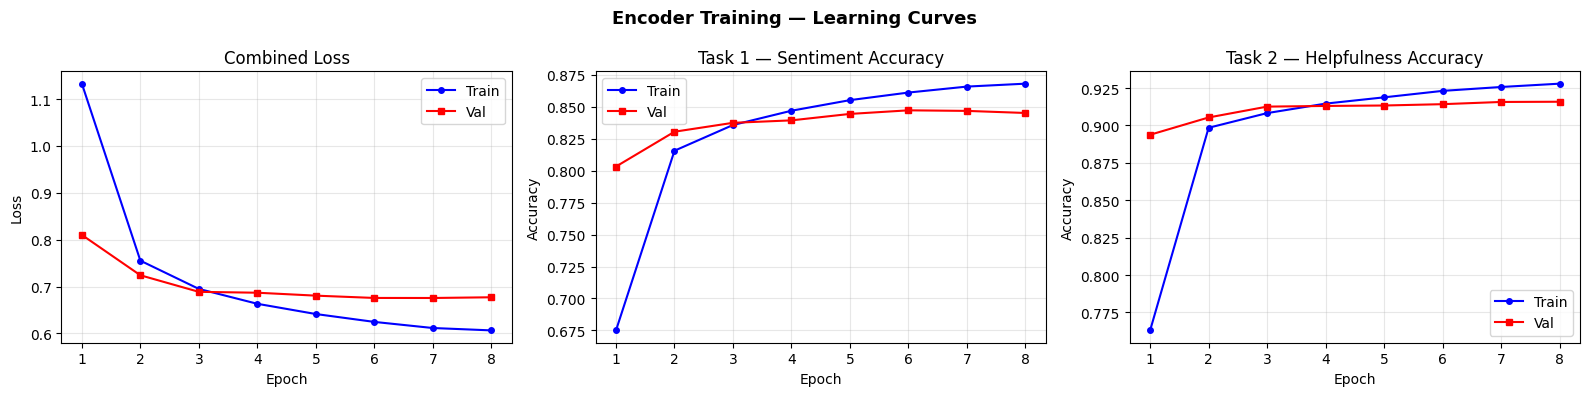

Saved → results/encoder_learning_curves.png


In [15]:
# ── Learning Curves ───────────────────────────────────────────────────────
eps = range(1, ENC_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Encoder Training — Learning Curves', fontsize=13, fontweight='bold')

axes[0].plot(eps, enc_history['tr_loss'], 'b-o', ms=4, label='Train')
axes[0].plot(eps, enc_history['va_loss'], 'r-s', ms=4, label='Val')
axes[0].set_title('Combined Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, enc_history['tr_s'], 'b-o', ms=4, label='Train')
axes[1].plot(eps, enc_history['va_s'], 'r-s', ms=4, label='Val')
axes[1].set_title('Task 1 — Sentiment Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(eps, enc_history['tr_h'], 'b-o', ms=4, label='Train')
axes[2].plot(eps, enc_history['va_h'], 'r-s', ms=4, label='Val')
axes[2].set_title('Task 2 — Helpfulness Accuracy'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/encoder_learning_curves.png")

Loading best encoder weights for test evaluation...

  TASK 1 — Sentiment Classification (Test Set)
              precision    recall  f1-score   support

    Negative       0.68      0.57      0.62       869
     Neutral       0.32      0.09      0.14       483
    Positive       0.89      0.97      0.92      5399

    accuracy                           0.85      6751
   macro avg       0.63      0.54      0.56      6751
weighted avg       0.82      0.85      0.83      6751

  TASK 2 — Helpfulness Classification (Test Set)
              precision    recall  f1-score   support

         Low       0.99      0.97      0.98      1966
      Medium       0.96      0.90      0.93      3857
        High       0.68      0.90      0.77       928

    accuracy                           0.92      6751
   macro avg       0.88      0.92      0.89      6751
weighted avg       0.93      0.92      0.92      6751



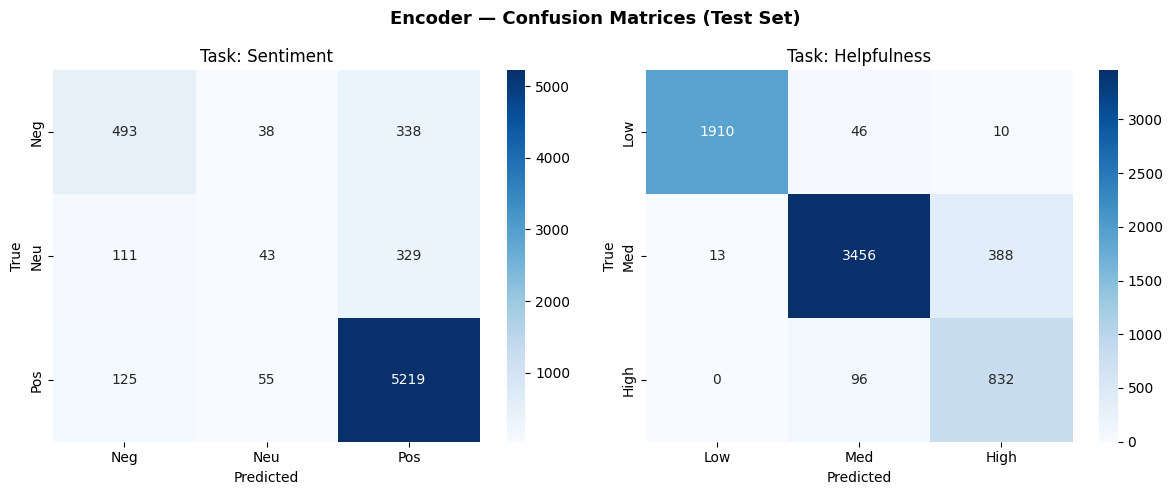

Saved → results/encoder_confusion_matrices.png
Saved → results/encoder_test_results.json


In [16]:
# ── Test-Set Evaluation ───────────────────────────────────────────────────
print("Loading best encoder weights for test evaluation...")
encoder.load_state_dict(torch.load('models/encoder_best.pt', map_location=DEVICE))
encoder.eval()

s_pred_all, s_true_all = [], []
h_pred_all, h_true_all = [], []

with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(DEVICE)
        sl, hl, _ = encoder(ids)
        s_pred_all.extend(sl.argmax(1).cpu().tolist())
        s_true_all.extend(batch['sentiment'].tolist())
        h_pred_all.extend(hl.argmax(1).cpu().tolist())
        h_true_all.extend(batch['helpfulness'].tolist())

print("\n" + "="*60)
print("  TASK 1 — Sentiment Classification (Test Set)")
print("="*60)
s_report = classification_report(s_true_all, s_pred_all,
               target_names=['Negative','Neutral','Positive'])
print(s_report)

print("="*60)
print("  TASK 2 — Helpfulness Classification (Test Set)")
print("="*60)
h_report = classification_report(h_true_all, h_pred_all,
               target_names=['Low','Medium','High'])
print(h_report)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Encoder — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, preds, labels, names, title in [
    (axes[0], s_pred_all, s_true_all, ['Neg','Neu','Pos'], 'Sentiment'),
    (axes[1], h_pred_all, h_true_all, ['Low','Med','High'], 'Helpfulness'),
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=names, yticklabels=names)
    ax.set_title(f'Task: {title}'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('results/encoder_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/encoder_confusion_matrices.png")

# Save results
with open('results/encoder_test_results.json', 'w') as f:
    json.dump({
        'sentiment':    classification_report(s_true_all, s_pred_all,
                            target_names=['Negative','Neutral','Positive'], output_dict=True),
        'helpfulness':  classification_report(h_true_all, h_pred_all,
                            target_names=['Low','Medium','High'], output_dict=True),
    }, f, indent=2)
print("Saved → results/encoder_test_results.json")

### Section 4.2 — Save Training Embeddings to Disk

The encoder's `cls_embed` (mean-pooled representation) is computed for every training sample  
and saved to `results/train_embeddings.npy`. This is the index used by the Part B retrieval module.  
We also save the metadata (text, labels) for display during retrieval quality analysis.

In [17]:
print("Generating and saving training set embeddings...")
print(f"  Processing {len(train_data):,} training reviews in batches of {BATCH_SIZE}...")

encoder.eval()
all_embeds, all_meta = [], []

with torch.no_grad():
    for start in range(0, len(train_data), BATCH_SIZE):
        chunk = train_data[start : start + BATCH_SIZE]
        ids   = torch.tensor(
            [encode_seq(r['text']) for r in chunk], dtype=torch.long
        ).to(DEVICE)
        _, _, emb = encoder(ids)
        all_embeds.append(emb.cpu().numpy())
        all_meta.extend(chunk)
        if (start // BATCH_SIZE + 1) % 20 == 0:
            pct = (start + len(chunk)) / len(train_data) * 100
            print(f"    [{pct:5.1f}%] processed {start + len(chunk):,} reviews", end='\r')

train_embeddings = np.vstack(all_embeds)   # (N_train, EMBED_DIM)
print(f"\n  Done! Embedding matrix shape: {train_embeddings.shape}")

np.save('results/train_embeddings.npy', train_embeddings)
with open('results/train_meta.pkl', 'wb') as f:
    pickle.dump(all_meta, f)

print(f"  Saved → results/train_embeddings.npy   ({train_embeddings.nbytes/1e6:.1f} MB)")
print(f"  Saved → results/train_meta.pkl         ({len(all_meta):,} records)")

Generating and saving training set embeddings...
  Processing 31,499 training reviews in batches of 128...
    [ 97.5%] processed 30,720 reviews
  Done! Embedding matrix shape: (31499, 128)
  Saved → results/train_embeddings.npy   (16.1 MB)
  Saved → results/train_meta.pkl         (31,499 records)
